In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Basic Libraries
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix
from sklearn.utils import class_weight

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Dataset (1)/RFMiD_Training_Labels.csv")
image_paths = "/content/drive/MyDrive/Dataset (1)/Training_Set/Training/" + df["ID"].astype(str) + ".png"

val_df= pd.read_csv("/content/drive/MyDrive/Dataset (1)/RFMiD_Validation_Labels.csv")
val_paths = "/content/drive/MyDrive/Dataset (1)/Validation/" + val_df["ID"].astype(str) + ".png"

test_df = pd.read_csv("/content/drive/MyDrive/Dataset1/RFMiD_Testing_Labels.csv")
test_paths = "/content/drive/MyDrive/Dataset1/Test/" + test_df["ID"].astype(str) + ".png"

labels = df["Disease_Risk"].to_numpy()
val_labels = val_df["Disease_Risk"].to_numpy()
test_labels = test_df["Disease_Risk"].to_numpy()

data = tf.data.Dataset.from_tensor_slices((image_paths, labels))
val = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, (224, 224))
    image = image/255.0
    return image, label

data = data.map(load_image).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
val = val.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)
test = test.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
#A custom Function to apply sobel Filter on the Dataset
def sobel_filter(image):
    gray = tf.image.rgb_to_grayscale(image)

    # Add batch dimension
    gray_expanded = tf.expand_dims(gray, axis=0)  # [1, H, W, 1]

    kernel_x = tf.constant([[-1, 0, 1],
                             [-2, 0, 2],
                             [-1, 0, 1]], dtype=tf.float32)

    kernel_y = tf.constant([[1, 2, 1],
                             [0, 0, 0],
                             [-1, -2, -1]], dtype=tf.float32)

    kernel_x = tf.reshape(kernel_x, [3, 3, 1, 1])
    kernel_y = tf.reshape(kernel_y, [3, 3, 1, 1])

    gx = tf.nn.conv2d(gray_expanded, kernel_x, strides=1, padding='SAME')
    gy = tf.nn.conv2d(gray_expanded, kernel_y, strides=1, padding='SAME')

    sobel = tf.sqrt(tf.square(gx) + tf.square(gy))

    # Remove batch dimension
    sobel = tf.squeeze(sobel, axis=0)  # [H, W, 1]

    # normalize
    if tf.reduce_max(sobel) != 0:
        sobel = sobel / tf.reduce_max(sobel)

    return gray, sobel

#Load Dataset

In [ ]:
data = tf.data.Dataset.from_tensor_slices((image_paths, labels))
val = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, (224, 224))
    image = tf.cast(image, tf.float32) / 255.0

    _, sobel = sobel_filter(image)

    # Convert back to 3-channel for model
    sobel = tf.image.grayscale_to_rgb(sobel)

    return sobel, label

data = data.map(load_image).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
val = val.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)
test = test.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)

#Visualize (after Applying filter)

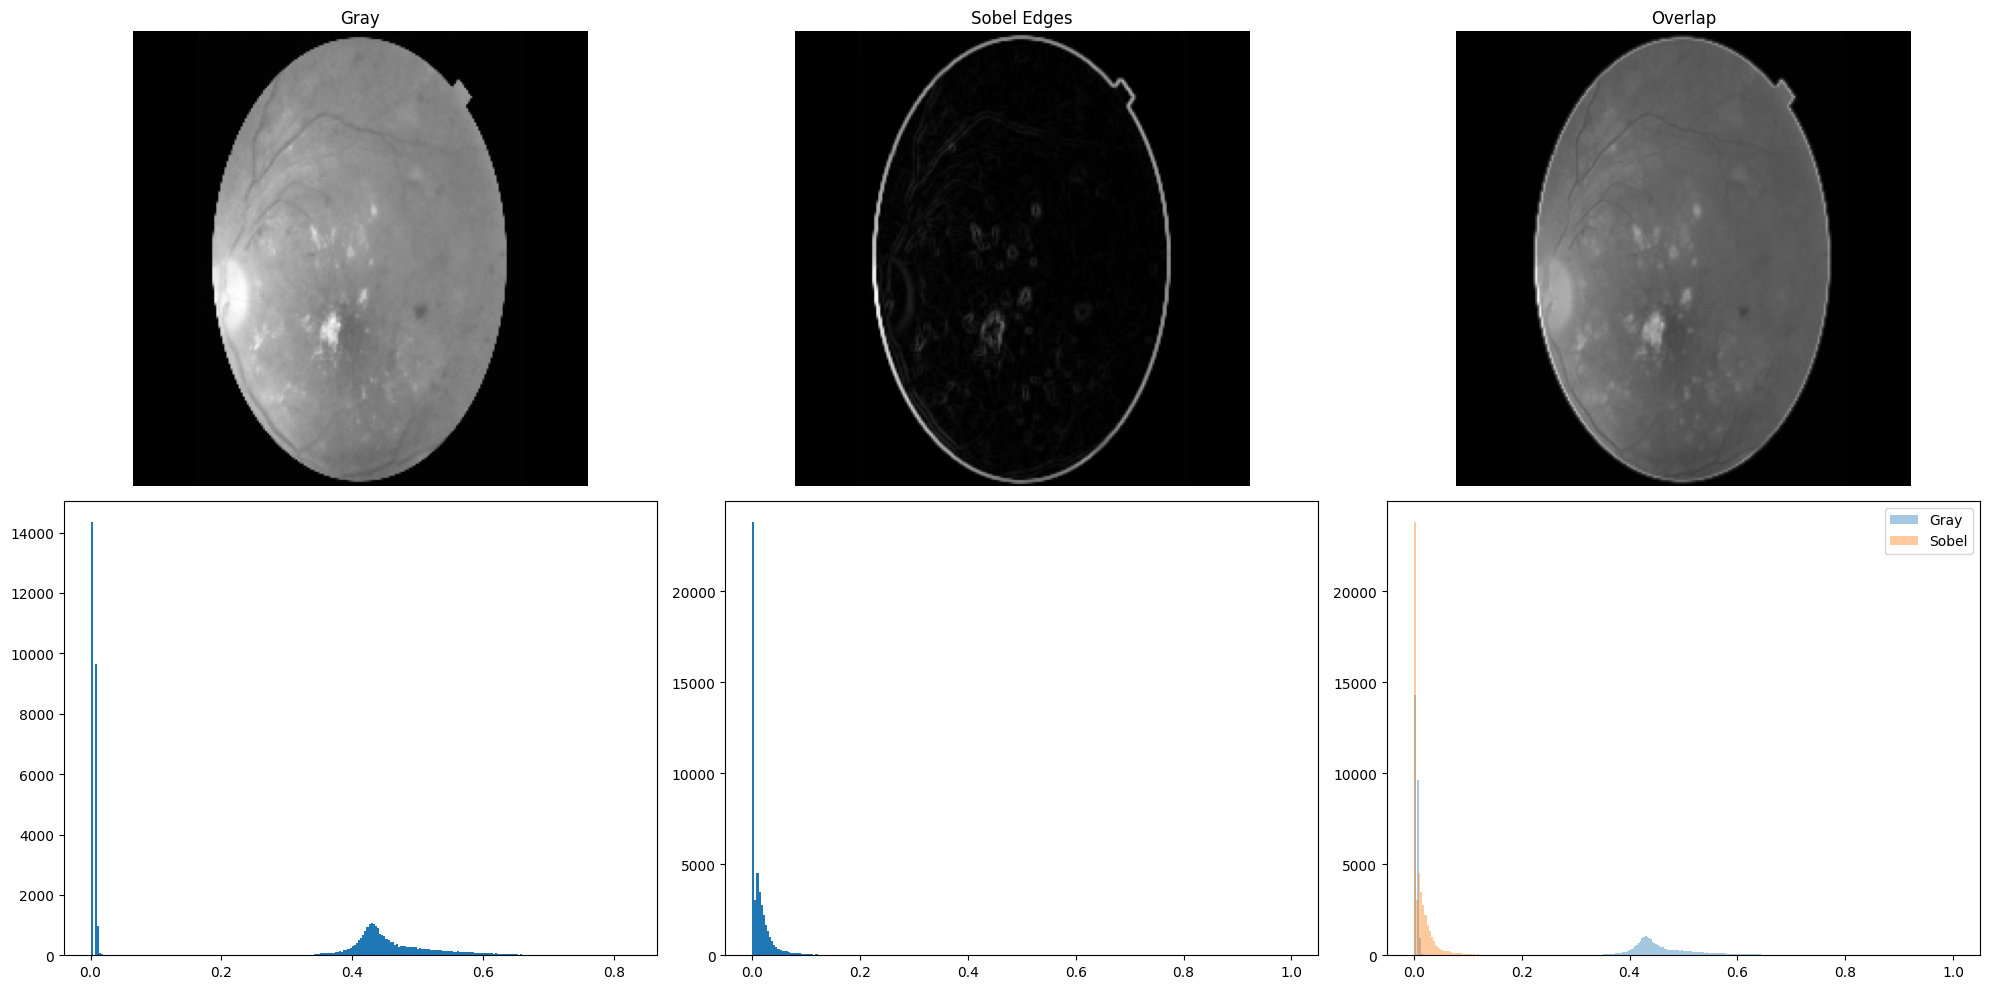

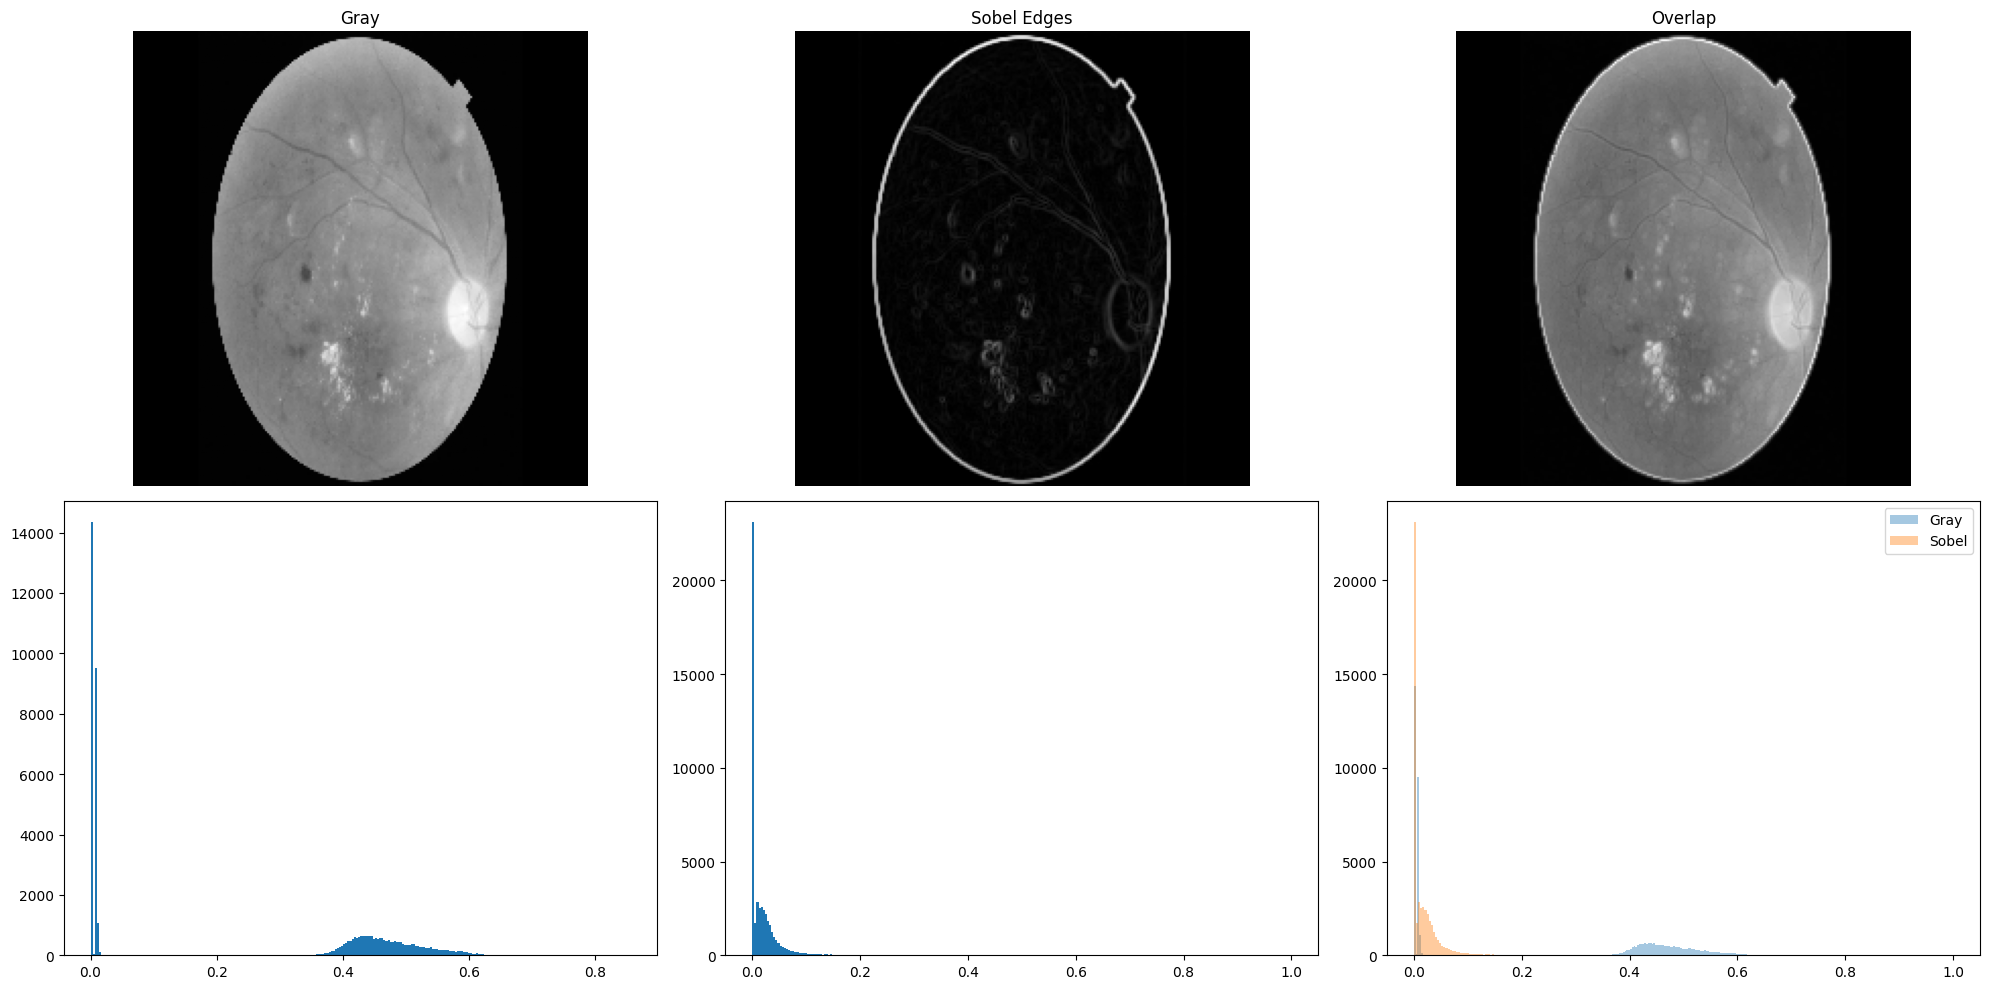

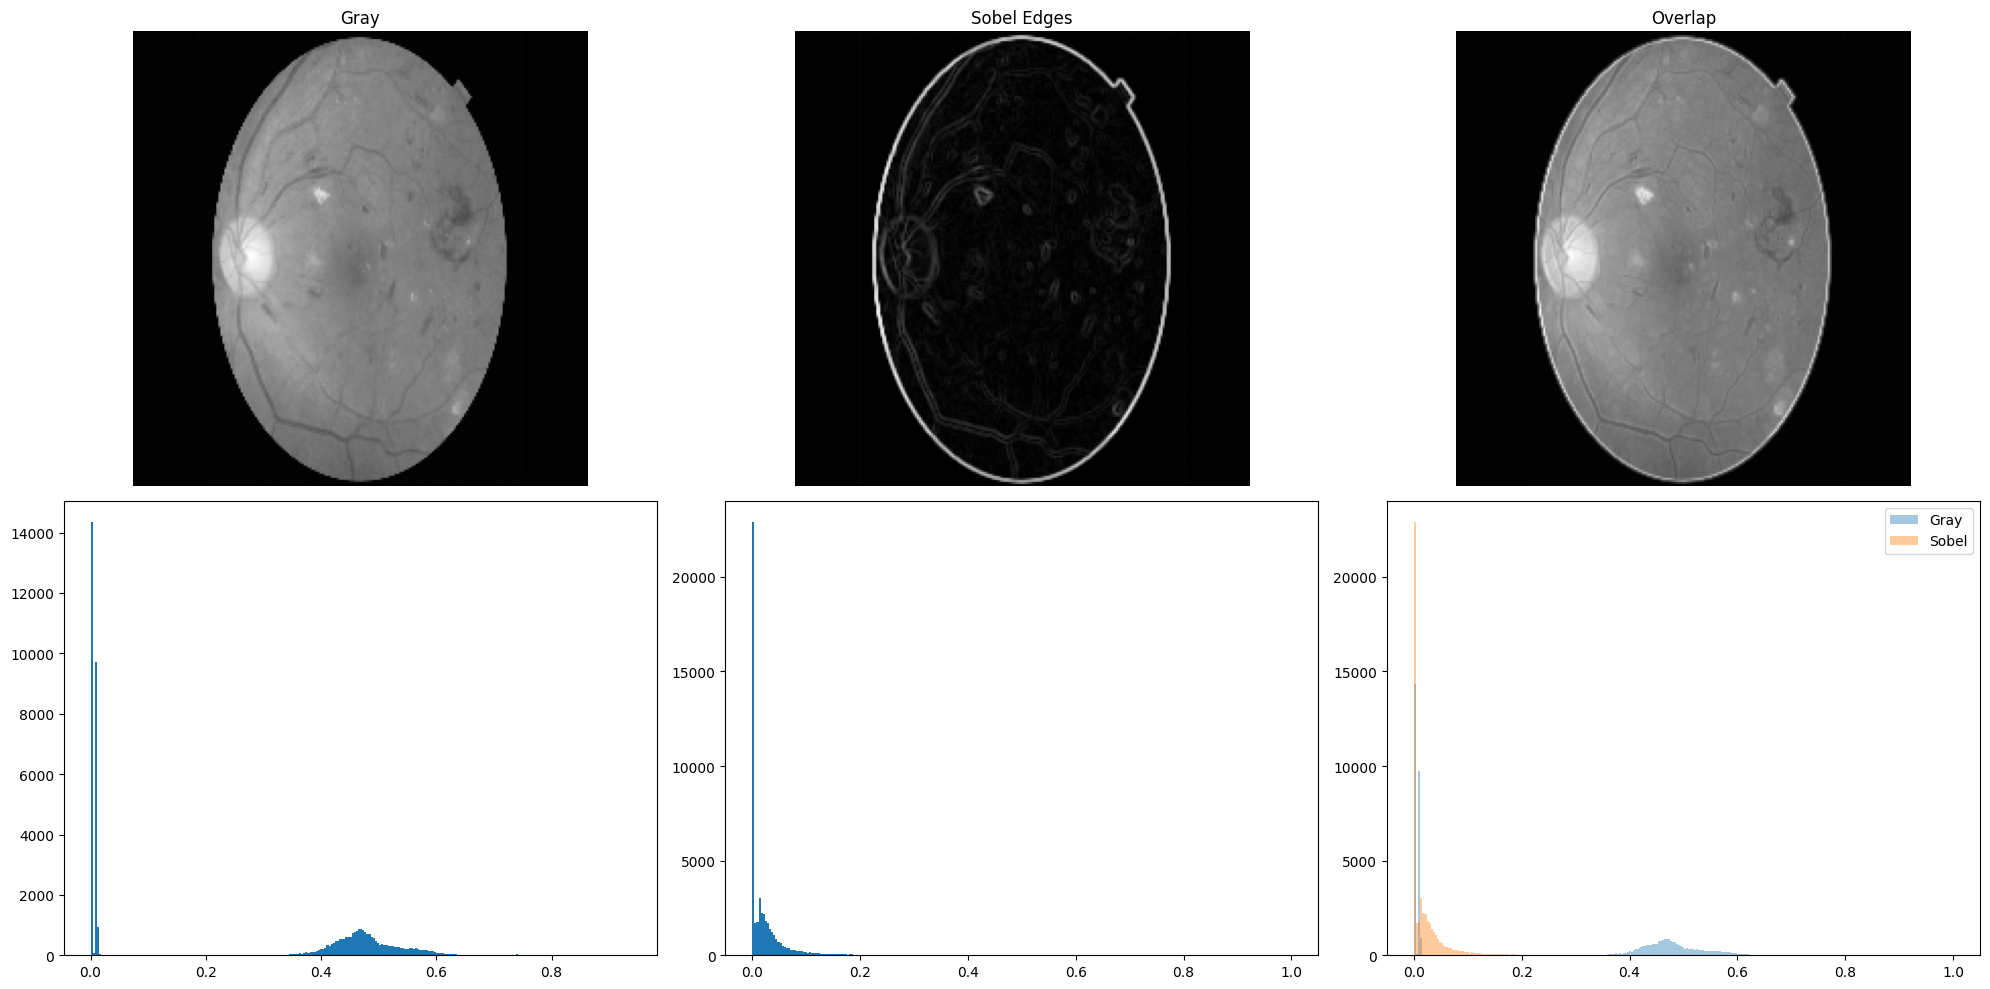

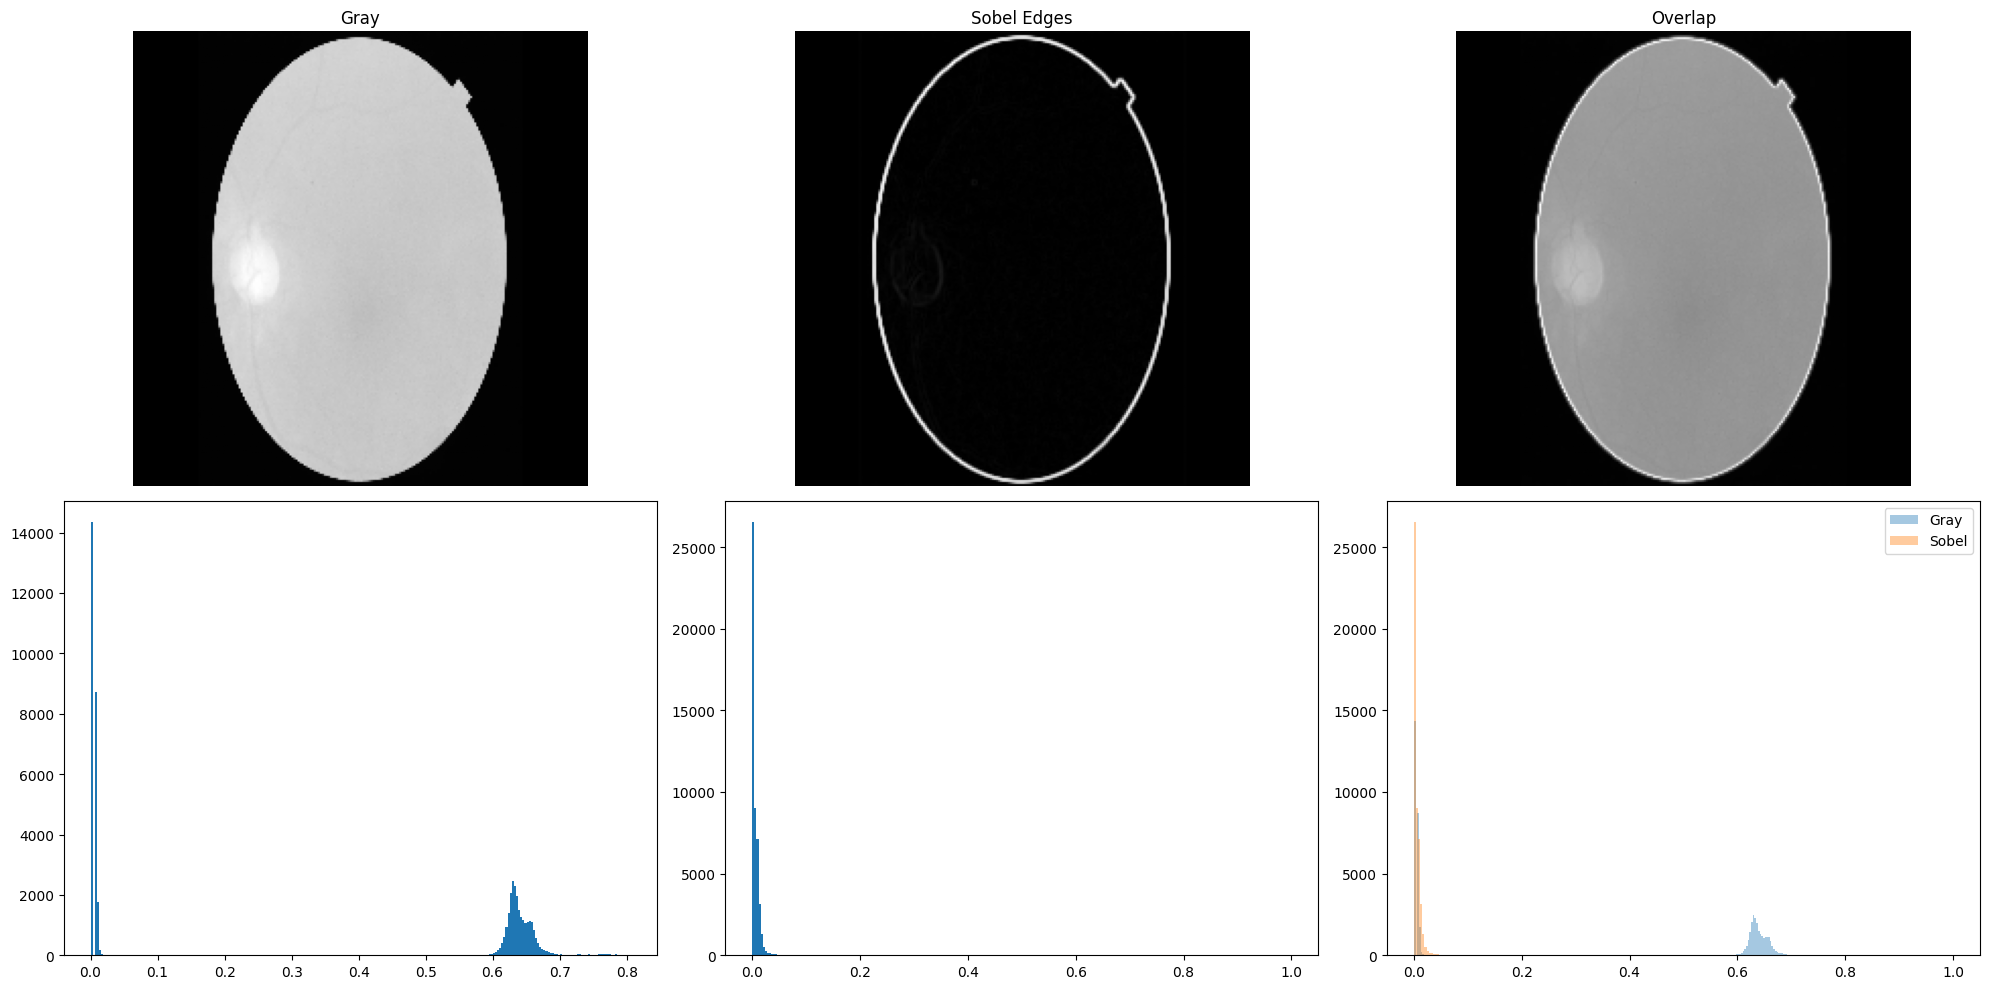

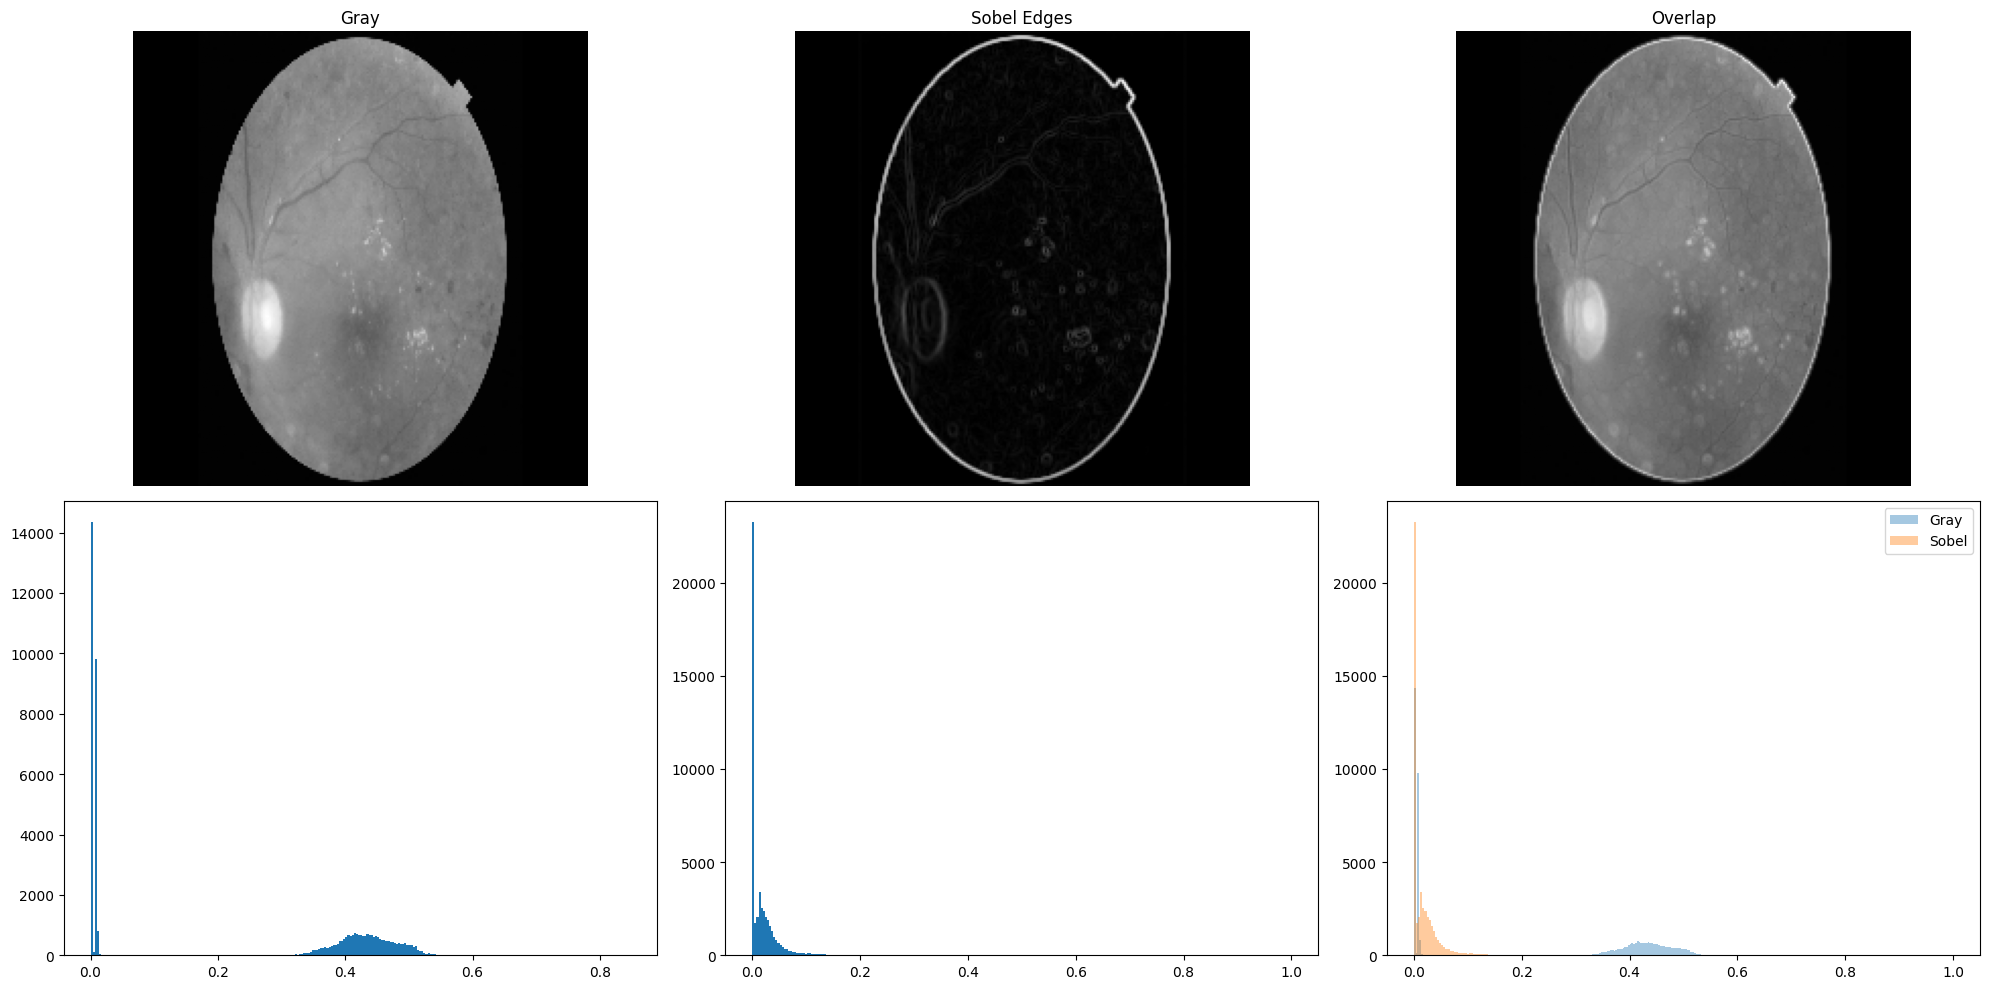

In [ ]:
sample_paths = image_paths[:5]

for path in sample_paths:
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.float32) / 255.0

    gray, sobel = sobel_filter(img)

    # Convert tensors → numpy
    gray = gray.numpy().squeeze()
    sobel = sobel.numpy().squeeze()

    sobel_edges = np.abs(sobel)

    overlap = 0.7 * gray + 0.3 * sobel_edges

    plt.figure(figsize=(20, 10))

    # Row 1
    plt.subplot(2, 3, 1)
    plt.imshow(gray, cmap='gray')
    plt.title("Gray")
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(sobel, cmap='gray')
    plt.title("Sobel Edges")
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(overlap, cmap='gray')
    plt.title("Overlap")
    plt.axis('off')

    # Row 2
    plt.subplot(2, 3, 4)
    plt.hist(gray.ravel(), bins=256)

    plt.subplot(2, 3, 5)
    plt.hist(sobel.ravel(), bins=256)

    plt.subplot(2, 3, 6)
    plt.hist(gray.ravel(), bins=256, alpha=0.4, label='Gray')
    plt.hist(sobel.ravel(), bins=256, alpha=0.4, label='Sobel')
    plt.legend()

    plt.tight_layout()
    plt.show()

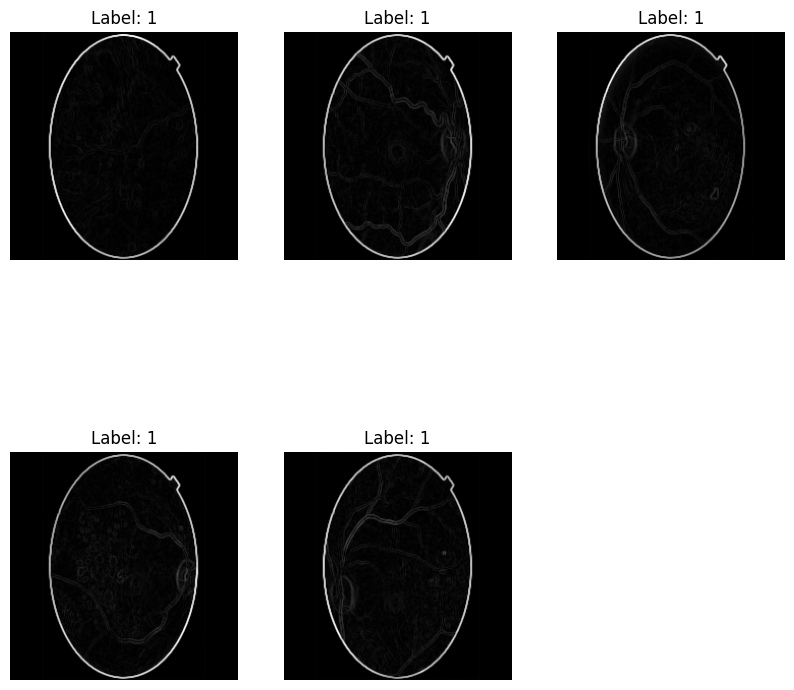

In [ ]:
img, label = next(iter(val))

plt.figure(figsize=(10,10))

for i in range(5):
    # Adjusted subplot to 5 rows and 4 columns to accommodate 20 images
    plt.subplot(2, 3, i + 1)
    plt.imshow((img[i].numpy()*255).astype("uint8"))
    plt.title(f"Label: {label[i].numpy()}") # Removed [0] as label[i].numpy() is already a scalar
    plt.axis("off")

plt.show()

In [ ]:
def build_model():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    # Unfreeze last few layers
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    # Custom classifier
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)

    x = layers.Dropout(0.5)(x)

    output = layers.Dense(1, activation='sigmoid')(x)

    # Final model
    model = models.Model(inputs=base_model.input, outputs=output)
    return model


# Instantiate model
model = build_model()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#Early Stop

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    mode='max')

#Class Imbalance

In [ ]:
# CORRECT — use the full training labels:
labels_np = df["Disease_Risk"].to_numpy()

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_np),
    y=labels_np)
class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(2.3940149625935163), 1: np.float64(0.6319947333772219)}


#Compile

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(),
        tf.keras.metrics.Precision()])
history = model.fit(data,validation_data=val,epochs=15,class_weight=class_weights,callbacks=[early_stop])

#model.summary()

Epoch 1/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 583s 6s/step - accuracy: 0.6193 - loss: 0.6883 - precision: 0.8294 - recall: 0.6531 - val_accuracy: 0.8031 - val_loss: 0.6457 - val_precision: 0.8074 - val_recall: 0.9862
Epoch 2/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 253s 3s/step - accuracy: 0.6432 - loss: 0.6396 - precision: 0.8576 - recall: 0.6583 - val_accuracy: 0.7922 - val_loss: 0.6311 - val_precision: 0.8539 - val_recall: 0.8893
Epoch 3/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 257s 3s/step - accuracy: 0.7203 - loss: 0.6147 - precision: 0.8703 - recall: 0.7597 - val_accuracy: 0.3656 - val_loss: 0.8053 - val_precision: 0.9167 - val_recall: 0.2174
Epoch 4/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 254s 3s/step - accuracy: 0.7130 - loss: 0.6044 - precision: 0.8656 - recall: 0.7544 - val_accuracy: 0.5234 - val_loss: 0.7424 - val_precision: 0.9241 - val_recall: 0.4328
Epoch 5/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 264s 3s/step - accuracy: 0.7240 - loss: 0.6004 - precision: 0.8783 - recall: 0.7558 - val_accuracy: 0.7781 - val_loss: 0.5799 

#Loss and Accuracy

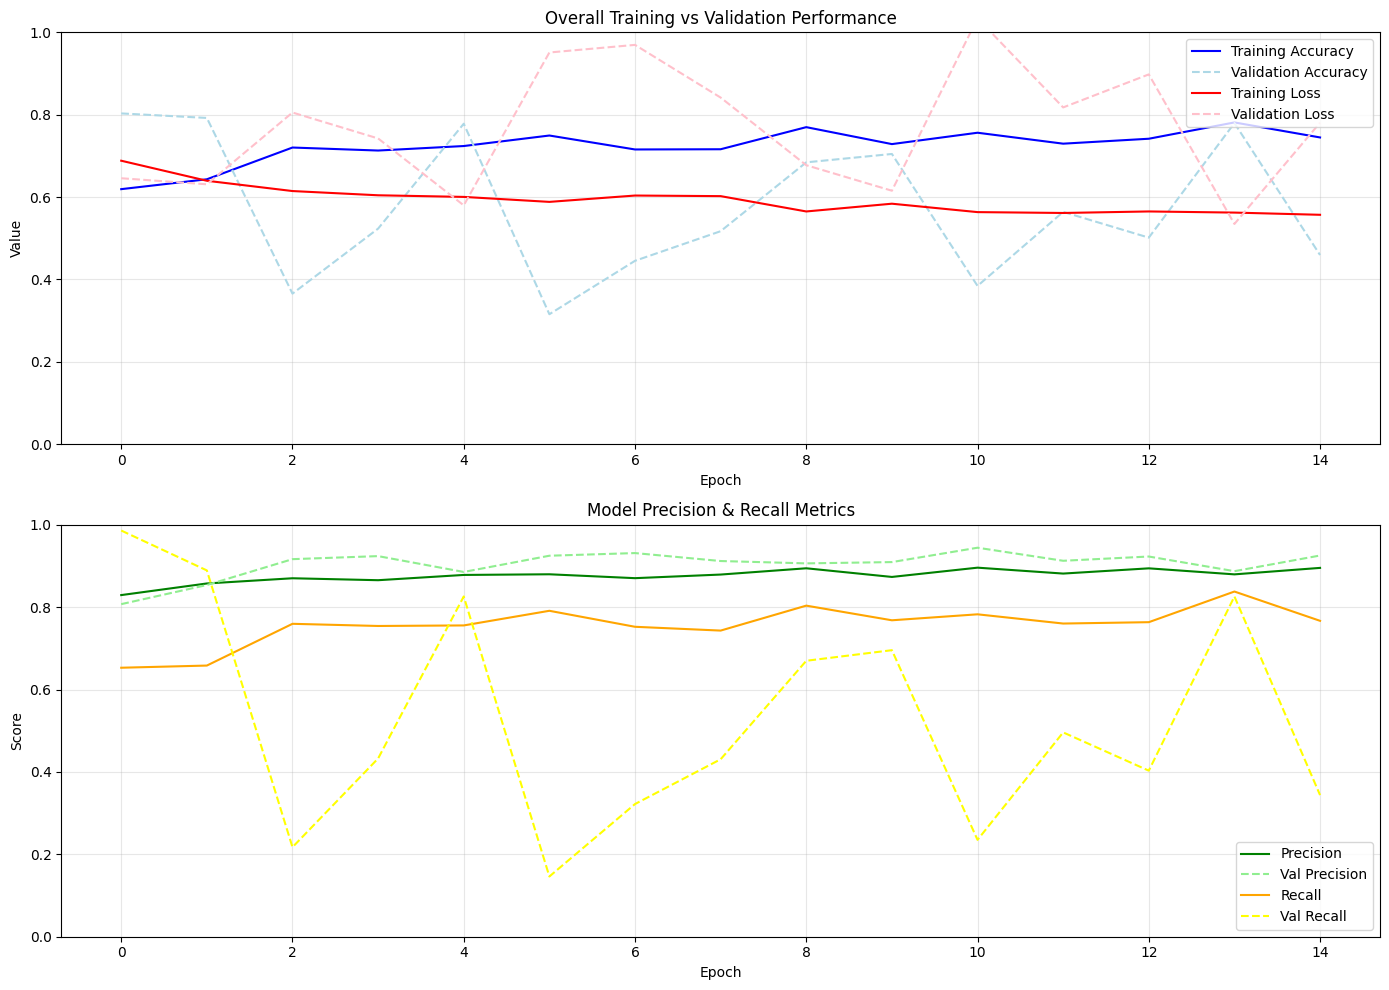

In [ ]:
plt.figure(figsize=(14, 10))

# 1. Accuracy and Loss (Your original requested plot)
plt.subplot(2, 1, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='lightblue', linestyle='--')
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='pink', linestyle='--')
plt.title("Overall Training vs Validation Performance")
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.ylim([0, 1])
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# 2. Precision and Recall (The new requested plot)
plt.subplot(2, 1, 2)
plt.plot(history.history['precision'], label='Precision', color='green')
plt.plot(history.history['val_precision'], label='Val Precision', color='lightgreen', linestyle='--')
plt.plot(history.history['recall'], label='Recall', color='orange')
plt.plot(history.history['val_recall'], label='Val Recall', color='yellow', linestyle='--')
plt.title("Model Precision & Recall Metrics")
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Evaluate

In [ ]:
test_loss, test_acc, test_recall, test_precision = model.evaluate(test)

print("Test Accuracy:", test_acc)
print("Test Recall:", test_recall)
print("Test Precision:", test_precision)

20/20 ━━━━━━━━━━━━━━━━━━━━ 173s 9s/step - accuracy: 0.4016 - loss: 1.0118 - precision: 0.9920 - recall: 0.2451
Test Accuracy: 0.40156251192092896
Test Recall: 0.2450592815876007
Test Precision: 0.9919999837875366


#Confusion Matrix

In [ ]:
y_pred = model.predict(test)

# Convert probabilities → 0/1
y_pred = (y_pred > 0.3).astype(int).flatten()
y_true = test_labels

print(confusion_matrix(y_true, y_pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step
[[125   9]
 [245 261]]


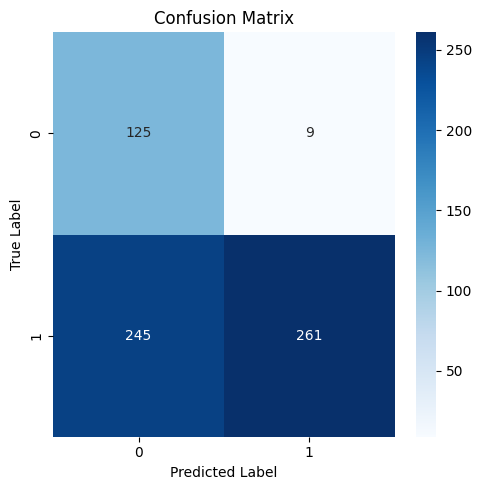

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


cm = np.array([[ 125,9],
               [ 245,261]])


plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()

plt.savefig('confusion_matrix.png')

In [ ]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.34      0.93      0.50       134
           1       0.97      0.52      0.67       506

    accuracy                           0.60       640
   macro avg       0.65      0.72      0.58       640
weighted avg       0.84      0.60      0.64       640



#Calculation

In [ ]:
import numpy as np

# Given confusion matrix
cm = np.array([[125, 9],
               [245, 261]])

# Extract values
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

# Metrics Calculation
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

# Print Results
print("\nModel Performance:\n")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1 Score     : {f1_score:.4f}")


Model Performance:

Accuracy     : 0.6031
Precision    : 0.9667
Recall       : 0.5158
Specificity  : 0.9328
F1 Score     : 0.6727
